# EDA & Seasonality Analysis — Fruit/Vegetable Price Dataset

**Schema:** `SN, Commodity, Date, Unit, Minimum, Maximum, Average`

This notebook covers:
1. Load & clean the data
2. Data quality checks (missingness, unit consistency, logic violations, duplicates)
3. Coverage report (date gaps per commodity)
4. Distribution & volatility ranking
5. Time series visualization
6. STL decomposition (trend / seasonal / residual) per commodity
7. Seasonality strength & peak-month summary
8. Year-over-year heatmaps

Output tables (`volatility_ranking.csv`, `seasonality_summary.csv`) feed directly into the clustering step later.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL
import os
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
%matplotlib inline

# ---- CONFIG: edit these ----
CSV_PATH = "D:/ShaunakKathavate Github/vegetable_and_fruits_time_series_and_clustering/data/raw/kalimati_tarkari_dataset.csv"      # <-- path to your dataset
DATE_COL = "Date"
COMMODITY_COL = "Commodity"
MIN_OBS_PER_COMMODITY = 200     # skip commodities with too few rows for STL
OUTPUT_DIR = "D:/ShaunakKathavate Github/vegetable_and_fruits_time_series_and_clustering/reports/from notebooks/eda_outputs"
TOP_N_PLOTS = 8                 # how many commodities to plot individually

os.makedirs(OUTPUT_DIR, exist_ok=True)

## 1. Load & Clean

In [2]:
df = pd.read_csv(CSV_PATH)
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce", dayfirst=False)

for col in ["Minimum", "Maximum", "Average"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.head()

,SN,Commodity,Date,Unit,Minimum,Maximum,Average
0,0,Tomato Big(Nepali),2013-06-16,Kg,35.0,40.0,37.5
1,1,Tomato Small(Local),2013-06-16,Kg,26.0,32.0,29.0
2,2,Potato Red,2013-06-16,Kg,20.0,21.0,20.5
3,3,Potato White,2013-06-16,Kg,15.0,16.0,15.5
4,4,Onion Dry (Indian),2013-06-16,Kg,28.0,30.0,29.0


In [3]:
n_before = len(df)
df = df.dropna(subset=[DATE_COL, COMMODITY_COL, "Average"])
print(f"Dropped {n_before - len(df)} rows with missing Date/Commodity/Average "
      f"({(n_before - len(df)) / n_before:.1%})")

# logical consistency: Minimum <= Average <= Maximum should hold
bad = df[(df["Minimum"] > df["Average"]) | (df["Average"] > df["Maximum"])
         | (df["Minimum"] > df["Maximum"])]
print(f"Rows violating Min <= Average <= Max: {len(bad)} ({len(bad)/len(df):.2%})")
df["logic_violation"] = df.index.isin(bad.index)
bad.head()

Dropped 0 rows with missing Date/Commodity/Average (0.0%)
Rows violating Min <= Average <= Max: 0 (0.00%)


,SN,Commodity,Date,Unit,Minimum,Maximum,Average


In [4]:
# duplicates: same commodity + date reported more than once
dupes = df.duplicated(subset=[COMMODITY_COL, DATE_COL]).sum()
print(f"Duplicate (Commodity, Date) rows: {dupes}")

df = (df.groupby([COMMODITY_COL, DATE_COL], as_index=False)
        .agg({"Unit": "first", "Minimum": "mean", "Maximum": "mean", "Average": "mean"}))
df = df.sort_values([COMMODITY_COL, DATE_COL]).reset_index(drop=True)

# engineered features
df["Price_Range"] = df["Maximum"] - df["Minimum"]
df["Price_Range_Pct"] = df["Price_Range"] / df["Average"].replace(0, np.nan)
df["Year"] = df[DATE_COL].dt.year
df["Month"] = df[DATE_COL].dt.month
df["Week"] = df[DATE_COL].dt.isocalendar().week
df["DayOfYear"] = df[DATE_COL].dt.dayofyear

print(f"Final shape: {df.shape}")
print(f"Date range: {df[DATE_COL].min().date()} to {df[DATE_COL].max().date()}")
print(f"Commodities: {df[COMMODITY_COL].nunique()}")
df.head()

Duplicate (Commodity, Date) rows: 0
Final shape: (197161, 12)
Date range: 2013-06-16 to 2021-05-13
Commodities: 132


,Commodity,Date,Unit,Minimum,Maximum,Average,Price_Range,Price_Range_Pct,Year,Month,Week,DayOfYear
0,Apple(Fuji),2019-05-31,KG,250.0,260.0,255.0,10.0,0.039216,2019,5,22,151
1,Apple(Fuji),2019-06-01,KG,250.0,260.0,255.0,10.0,0.039216,2019,6,22,152
2,Apple(Fuji),2019-06-02,KG,250.0,260.0,255.0,10.0,0.039216,2019,6,22,153
3,Apple(Fuji),2019-06-03,KG,250.0,260.0,255.0,10.0,0.039216,2019,6,23,154
4,Apple(Fuji),2019-06-04,KG,340.0,350.0,345.0,10.0,0.028986,2019,6,23,155


## 2. Data Quality Checks

### 2a. Unit consistency
Comparing prices across commodities (or over time for the same commodity) only makes sense if the unit is consistent. Flag any commodity reported under more than one unit.

In [5]:
multi_unit = df.groupby(COMMODITY_COL)["Unit"].nunique()
offenders = multi_unit[multi_unit > 1]

if len(offenders):
    print("⚠ Commodities reported under multiple units (check before comparing):")
    display(offenders)
else:
    print("✓ All commodities use a single consistent unit.")

✓ All commodities use a single consistent unit.


### 2b. Coverage report
For each commodity: how many observations vs. how many calendar days in its date span. Low coverage means daily-frequency modeling will be noisy — those commodities may need resampling to weekly/monthly.

In [6]:
rows = []
for name, g in df.groupby(COMMODITY_COL):
    span_days = (g[DATE_COL].max() - g[DATE_COL].min()).days + 1
    n_obs = len(g)
    coverage = n_obs / span_days if span_days else np.nan
    rows.append({
        "Commodity": name, "n_obs": n_obs,
        "start": g[DATE_COL].min().date(), "end": g[DATE_COL].max().date(),
        "span_days": span_days, "coverage_pct": coverage
    })

cov = pd.DataFrame(rows).sort_values("coverage_pct")
cov.to_csv(f"{OUTPUT_DIR}/coverage_report.csv", index=False)

print("Sparsest commodities (lowest coverage — may need resampling/imputation):")
cov.head(10)

Sparsest commodities (lowest coverage — may need resampling/imputation):


,Commodity,n_obs,start,end,span_days,coverage_pct
78,Musk Melon,10,2014-12-09,2020-11-21,2175,0.004598
115,Sweet Lime,14,2013-06-30,2020-11-16,2697,0.005191
69,Mandarin,68,2013-11-04,2020-11-14,2568,0.026480
68,Maize,24,2013-06-30,2015-01-25,575,0.041739
129,Water Melon(Dotted),42,2019-06-04,2021-04-29,696,0.060345
72,Mango(Dushari),58,2019-06-04,2021-05-13,710,0.081690
112,Strawberry,234,2014-01-07,2021-05-13,2684,0.087183
67,Litchi(Local),215,2014-05-26,2020-07-16,2244,0.095811
66,Litchi(Indian),41,2019-06-04,2020-06-27,390,0.105128
8,Bauhania flower,286,2014-02-28,2021-04-27,2616,0.109327


In [7]:
cov.tail(10)  # densest / most complete commodities

,Commodity,n_obs,start,end,span_days,coverage_pct
96,Potato Red,2746,2013-06-16,2021-05-13,2889,0.950502
103,Raddish White(Local),2747,2013-06-16,2021-05-13,2889,0.950848
25,Chilli Dry,2748,2013-06-16,2021-05-13,2889,0.951194
16,Cabbage(Local),2749,2013-06-16,2021-05-13,2889,0.951540
21,Cauli Local,2750,2013-06-16,2021-05-13,2889,0.951886
53,Ginger,2751,2013-06-16,2021-05-13,2889,0.952233
76,Mushroom(Button),683,2019-05-31,2021-05-13,714,0.956583
126,Tomato Small(Tunnel),686,2019-05-31,2021-05-13,714,0.960784
61,Kiwi,183,2020-10-21,2021-04-28,190,0.963158
102,Raddish White(Hybrid),691,2019-06-04,2021-05-13,710,0.973239


## 3. Distribution & Volatility Ranking

In [8]:
stats = df.groupby(COMMODITY_COL)["Average"].agg(["mean", "std", "count"])
stats["cv"] = stats["std"] / stats["mean"]  # coefficient of variation
range_pct = df.groupby(COMMODITY_COL)["Price_Range_Pct"].mean()
stats["avg_daily_range_pct"] = range_pct
stats = stats.sort_values("cv", ascending=False)
stats.to_csv(f"{OUTPUT_DIR}/volatility_ranking.csv")

print("Most volatile commodities (high CV = unstable pricing):")
display(stats.head(10)[["mean", "cv", "avg_daily_range_pct"]])

print("\nMost stable commodities (low CV):")
display(stats.tail(10)[["mean", "cv", "avg_daily_range_pct"]])

Most volatile commodities (high CV = unstable pricing):


,mean,cv,avg_daily_range_pct
Commodity,,,
Maize,9.875000,1.356016,0.151657
Coriander Green,123.490514,0.769772,0.124566
Guava,58.578161,0.666015,0.148902
Onion Dry (Indian),47.476112,0.648452,0.064976
Cauli Terai,27.397875,0.595587,0.212307
Pear(Local),99.864186,0.573515,0.117239
Bauhania flower,119.169580,0.569476,0.118274
Pointed Gourd(Local),60.556195,0.555333,0.115342
Parseley,148.839249,0.541476,0.088084



Most stable commodities (low CV):


,mean,cv,avg_daily_range_pct
Commodity,,,
Papaya(Indian),94.876497,0.166619,0.109154
Apple(Fuji),280.025316,0.142566,0.064812
Litchi(Indian),142.621951,0.127006,0.080637
Fish Fresh(Rahu),282.147854,0.093017,0.025102
Fish Fresh,234.909624,0.073380,0.036398
Fish Fresh(Mungari),243.430048,0.072012,0.029748
Fish Fresh(Chhadi),213.613312,0.055731,0.041903
Fish Fresh(Bachuwa),220.534865,0.053997,0.036244
Mango(Calcutte),133.913043,0.052751,0.123579


Top commodities by observation count: ['Ginger', 'Cauli Local', 'Cabbage(Local)', 'Chilli Dry', 'Raddish White(Local)', 'Potato Red', 'Bamboo Shoot', 'Banana']


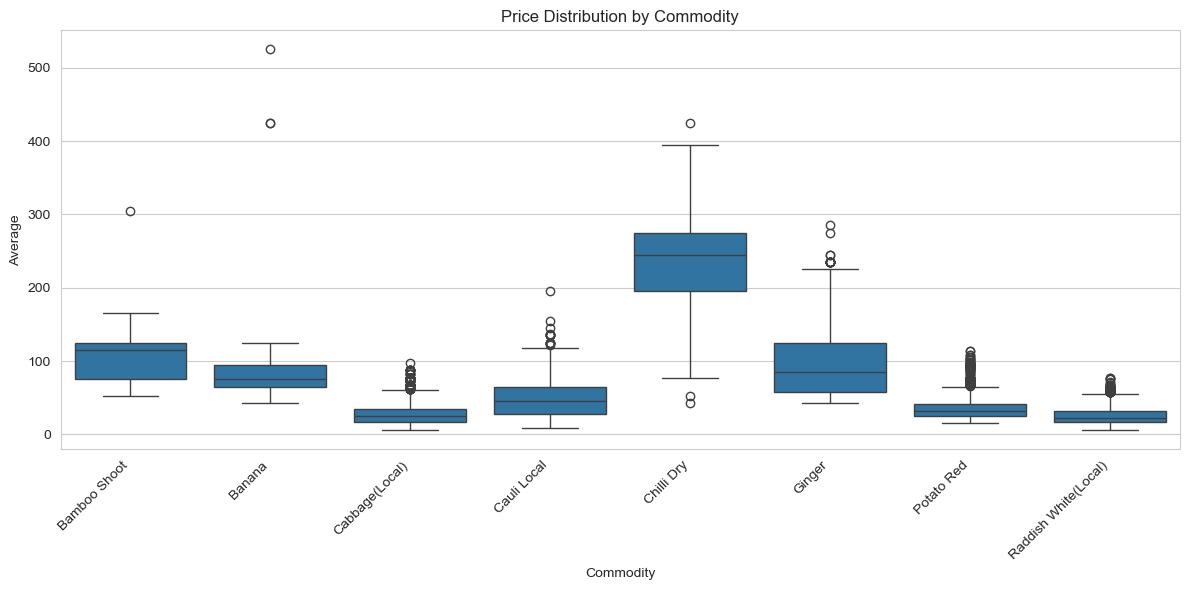

In [9]:
top_commodities = df[COMMODITY_COL].value_counts().head(TOP_N_PLOTS).index.tolist()
print("Top commodities by observation count:", top_commodities)

fig, ax = plt.subplots(figsize=(12, 6))
subset = df[df[COMMODITY_COL].isin(top_commodities)]
sns.boxplot(data=subset, x=COMMODITY_COL, y="Average", ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_title("Price Distribution by Commodity")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/price_distributions.png", dpi=150)
plt.show()

## 4. Time Series Visualization

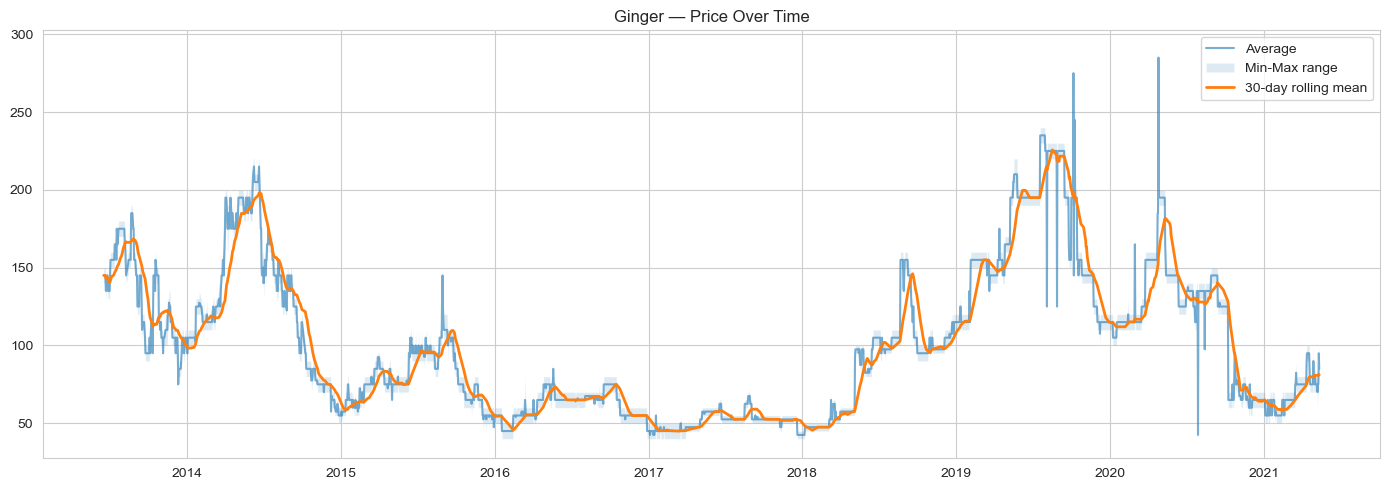

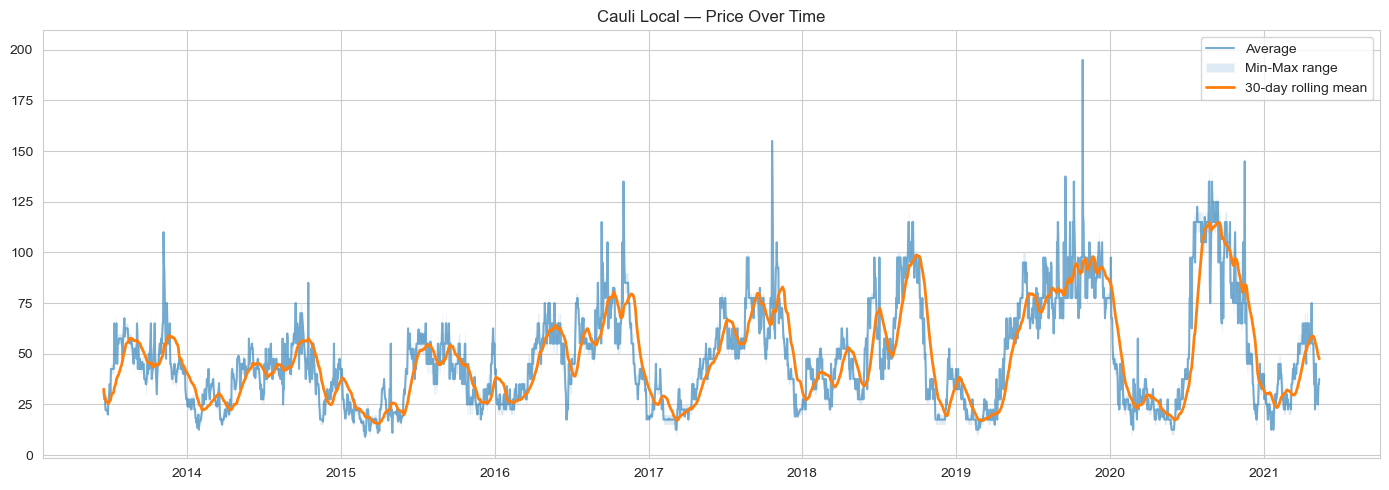

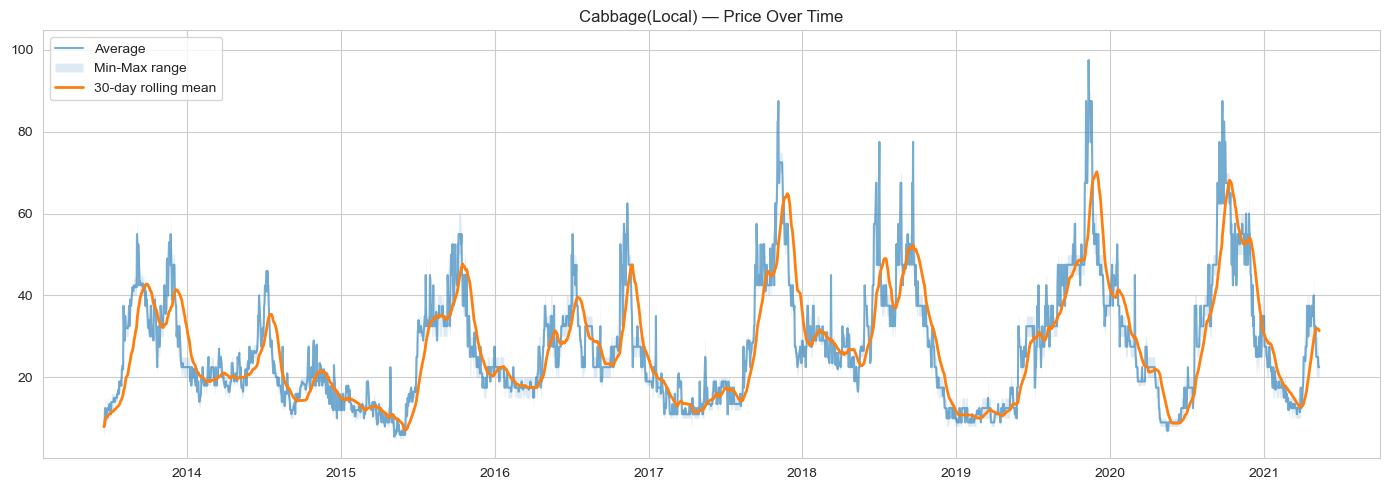

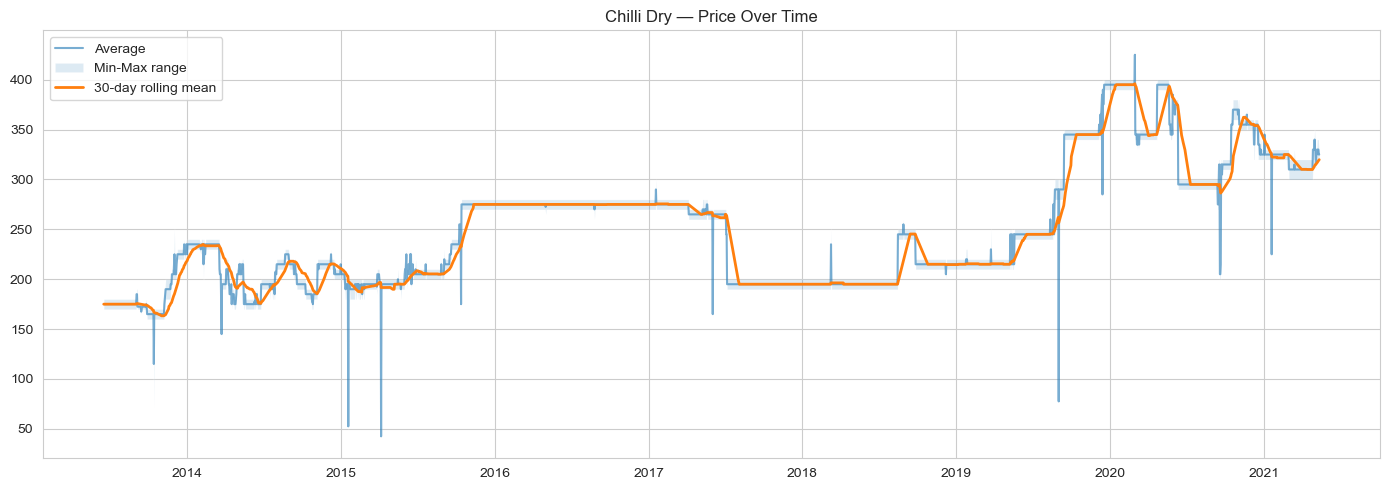

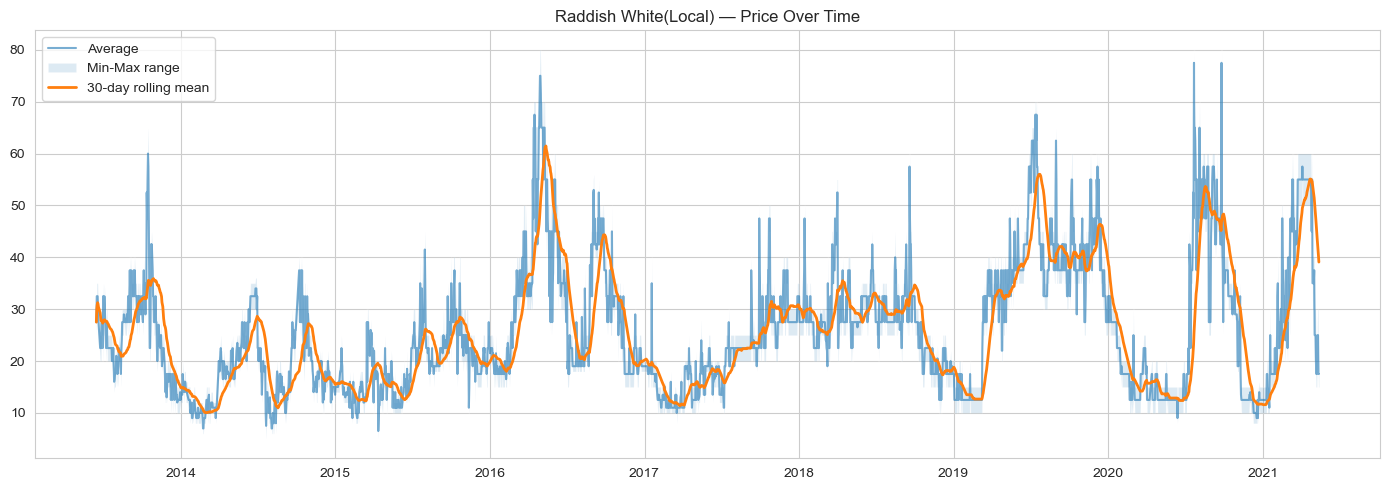

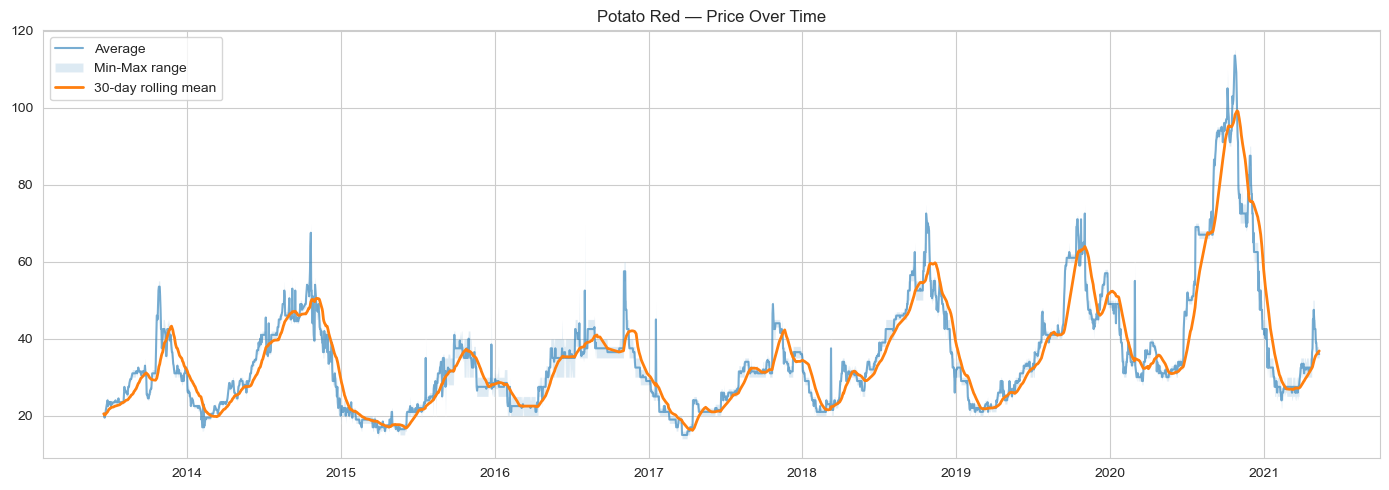

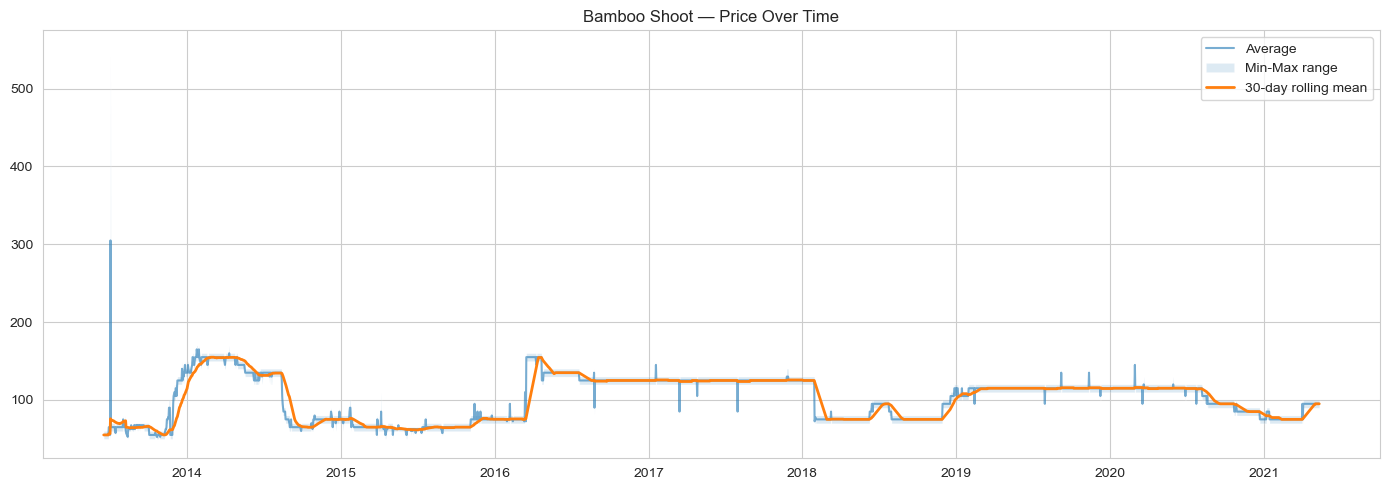

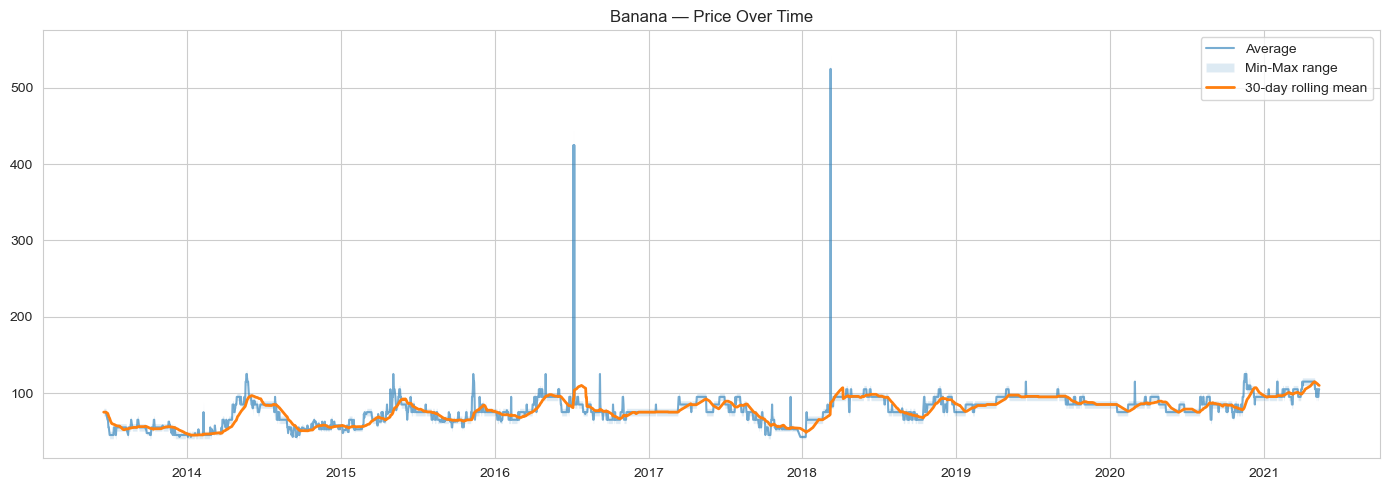

In [10]:
def plot_commodity_series(df, commodity, resample="D"):
    g = df[df[COMMODITY_COL] == commodity].set_index(DATE_COL).sort_index()
    if resample != "D":
        g = g.resample(resample).mean(numeric_only=True)

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(g.index, g["Average"], label="Average", alpha=0.6)
    ax.fill_between(g.index, g["Minimum"], g["Maximum"], alpha=0.15, label="Min-Max range")
    ax.plot(g.index, g["Average"].rolling(30, min_periods=1).mean(),
            label="30-day rolling mean", linewidth=2)
    ax.set_title(f"{commodity} — Price Over Time")
    ax.legend()
    plt.tight_layout()
    safe_name = commodity.replace("/", "_").replace(" ", "_")
    plt.savefig(f"{OUTPUT_DIR}/timeseries_{safe_name}.png", dpi=150)
    plt.show()

for c in top_commodities:
    plot_commodity_series(df, c)

## 5. STL Decomposition

Splits each commodity's price series into **trend**, **seasonal**, and **residual** components. Requires a regular daily index, so gaps up to 2 weeks are interpolated (longer gaps are left as missing and excluded).

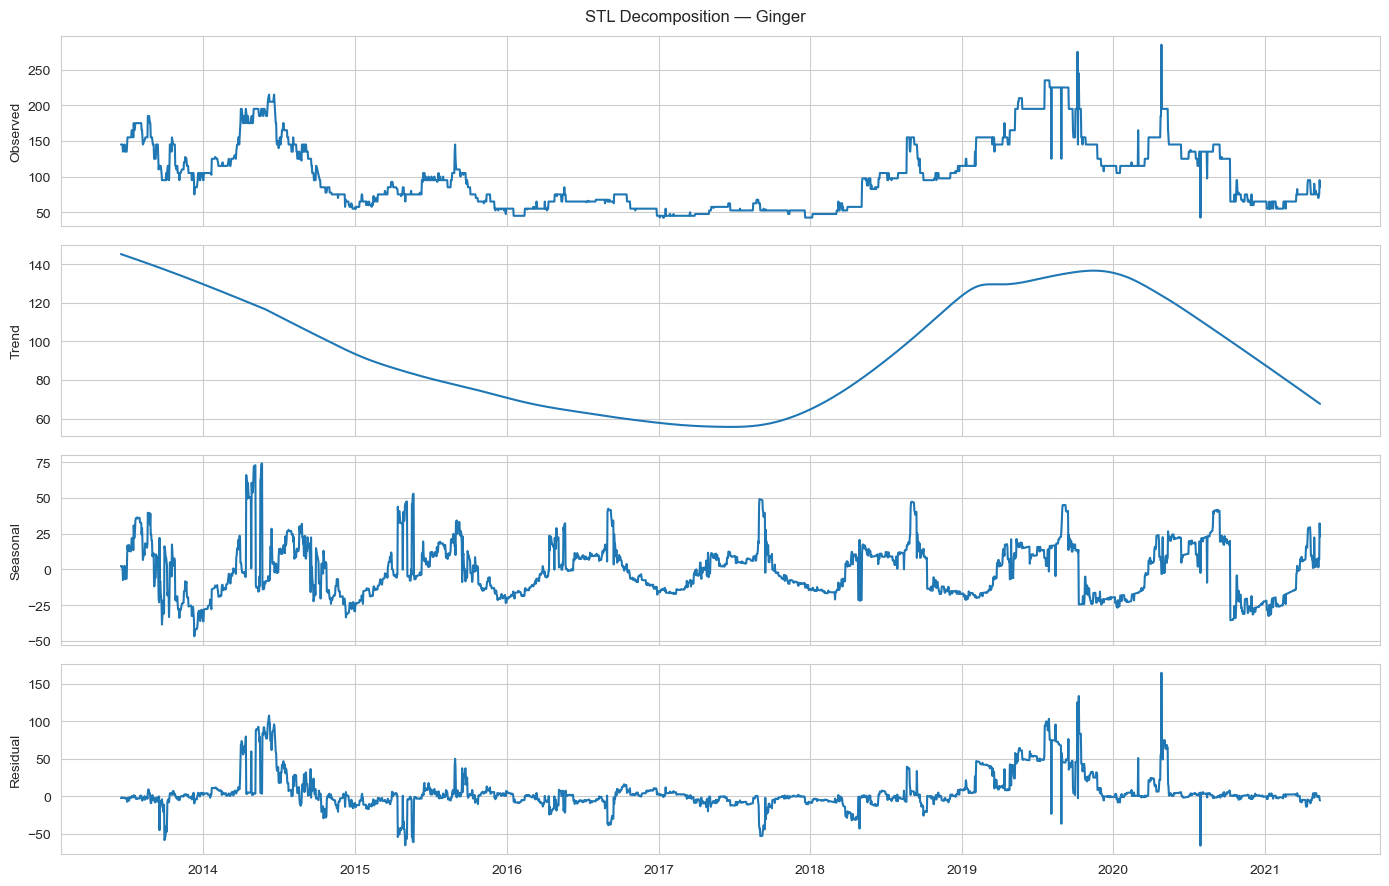

In [11]:
def stl_decompose_commodity(df, commodity, period=365, plot=True):
    g = (df[df[COMMODITY_COL] == commodity]
         .set_index(DATE_COL)["Average"]
         .sort_index()
         .asfreq("D"))
    g = g.interpolate(limit=14)
    g = g.dropna()

    if len(g) < period * 1.5:
        print(f"  Skipping STL for {commodity}: only {len(g)} usable days "
              f"(need ~{int(period*1.5)})")
        return None

    stl = STL(g, period=period, robust=True)
    res = stl.fit()

    if plot:
        fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
        axes[0].plot(g.index, res.observed); axes[0].set_ylabel("Observed")
        axes[1].plot(g.index, res.trend); axes[1].set_ylabel("Trend")
        axes[2].plot(g.index, res.seasonal); axes[2].set_ylabel("Seasonal")
        axes[3].plot(g.index, res.resid); axes[3].set_ylabel("Residual")
        fig.suptitle(f"STL Decomposition — {commodity}")
        plt.tight_layout()
        safe_name = commodity.replace("/", "_").replace(" ", "_")
        plt.savefig(f"{OUTPUT_DIR}/stl_{safe_name}.png", dpi=150)
        plt.show()

    # seasonality / trend strength (Hyndman & Athanasopoulos)
    seasonal_strength = max(0, 1 - res.resid.var() / (res.seasonal + res.resid).var())
    trend_strength = max(0, 1 - res.resid.var() / (res.trend + res.resid).var())

    seasonal_by_month = res.seasonal.groupby(res.seasonal.index.month).mean()
    peak_month = seasonal_by_month.idxmax()

    return {
        "Commodity": commodity,
        "seasonal_strength": round(seasonal_strength, 3),
        "trend_strength": round(trend_strength, 3),
        "peak_month": peak_month,
        "n_days_used": len(g),
    }

# demo: decompose one commodity with plots
_ = stl_decompose_commodity(df, top_commodities[0])

In [12]:
# run for all eligible commodities (no plots, just the summary table)
results = []
commodity_counts = df[COMMODITY_COL].value_counts()
eligible = commodity_counts[commodity_counts >= MIN_OBS_PER_COMMODITY].index

print(f"Running STL for {len(eligible)} commodities "
      f"(skipping {len(commodity_counts) - len(eligible)} with <{MIN_OBS_PER_COMMODITY} obs)...")

for c in eligible:
    r = stl_decompose_commodity(df, c, plot=False)
    if r:
        results.append(r)

seasonality_df = pd.DataFrame(results).sort_values("seasonal_strength", ascending=False)
seasonality_df.to_csv(f"{OUTPUT_DIR}/seasonality_summary.csv", index=False)

print("Strongest seasonal patterns:")
seasonality_df.head(10)

Running STL for 119 commodities (skipping 13 with <200 obs)...
  Skipping STL for Tomato Big(Indian): only 518 usable days (need ~547)
  Skipping STL for Pear(Chinese): only 458 usable days (need ~547)
  Skipping STL for Chilli Green(Machhe): only 507 usable days (need ~547)
  Skipping STL for Apple(Fuji): only 415 usable days (need ~547)
  Skipping STL for Tomato Small(Indian): only 474 usable days (need ~547)
  Skipping STL for Cauli Local(Jyapu): only 359 usable days (need ~547)
  Skipping STL for Kinnow: only 462 usable days (need ~547)
  Skipping STL for Cowpea(Short): only 438 usable days (need ~547)
  Skipping STL for Carrot(Terai): only 348 usable days (need ~547)
  Skipping STL for Cabbage: only 328 usable days (need ~547)
  Skipping STL for Bauhania flower: only 428 usable days (need ~547)
  Skipping STL for Tomato Small(Terai): only 322 usable days (need ~547)
  Skipping STL for Orange(Indian): only 351 usable days (need ~547)
  Skipping STL for Potato Red(Mude): only 274 us

,Commodity,seasonal_strength,trend_strength,peak_month,n_days_used
98,Guava,0.970,0.918,5,706
96,Chilli Green(Akbare),0.970,0.945,2,560
100,Drumstick,0.962,0.788,12,681
89,Fish Fresh(Chhadi),0.955,0.543,3,650
85,Papaya(Indian),0.904,0.772,1,710
84,Squash(Round),0.902,0.107,7,710
90,Fish Fresh(Bachuwa),0.900,0.000,5,650
99,Turnip,0.896,0.864,5,614
82,Tomato Small(Tunnel),0.885,0.056,9,714
97,Sugarcane,0.883,0.000,5,672


In [13]:
seasonality_df.tail(10)  # weakest / least seasonal commodities

,Commodity,seasonal_strength,trend_strength,peak_month,n_days_used
55,Arum,0.082,0.429,5,2338
74,Yam,0.066,0.416,10,1334
32,Pomegranate,0.060,0.337,6,2830
43,Celery,0.050,0.502,10,2659
46,Potato White,0.034,0.182,11,2635
25,Tofu,0.011,0.456,8,2854
70,Neuro,0.000,0.545,12,1578
59,Mombin,0.000,0.054,4,1922
44,Parseley,0.000,0.627,5,2592
6,Bamboo Shoot,0.000,0.205,4,2889


## 6. Year-over-Year Heatmaps

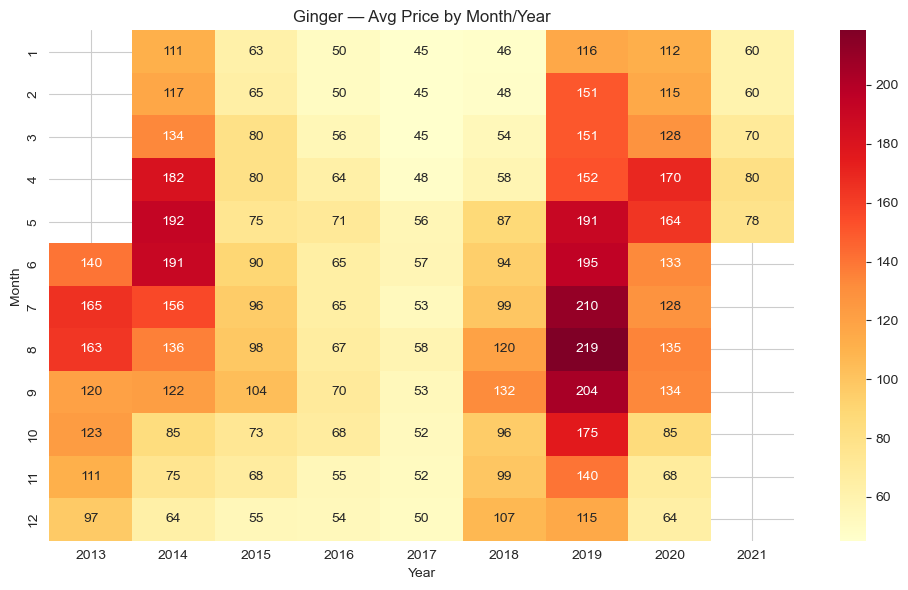

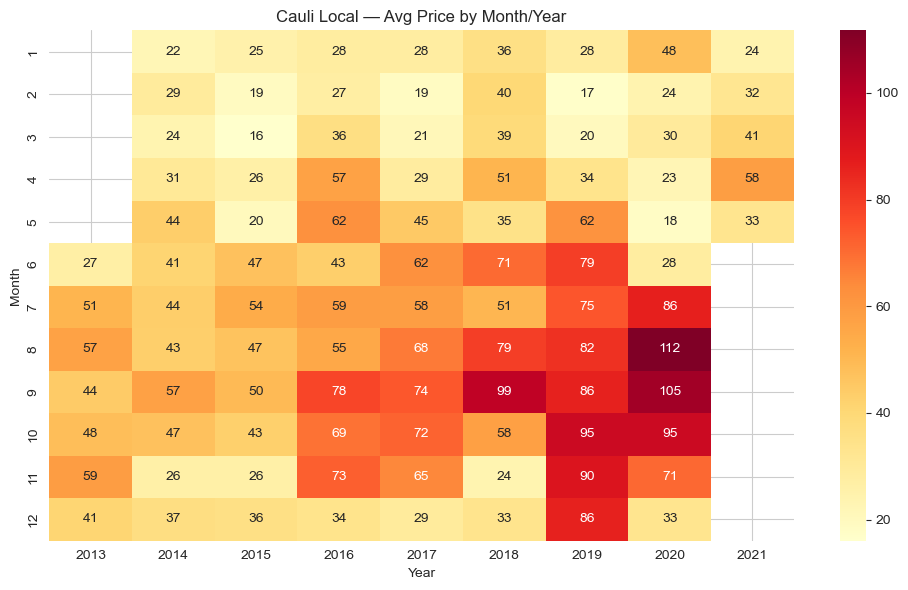

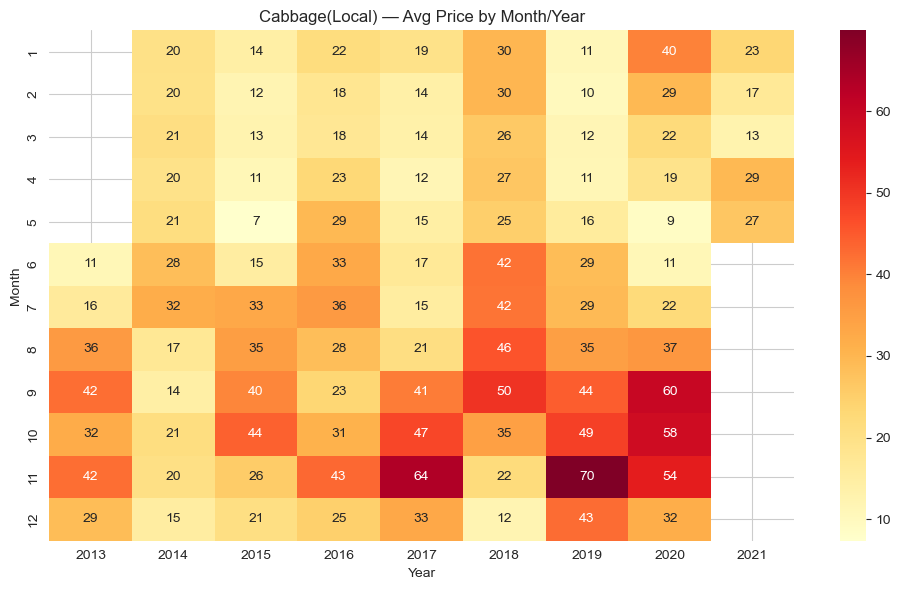

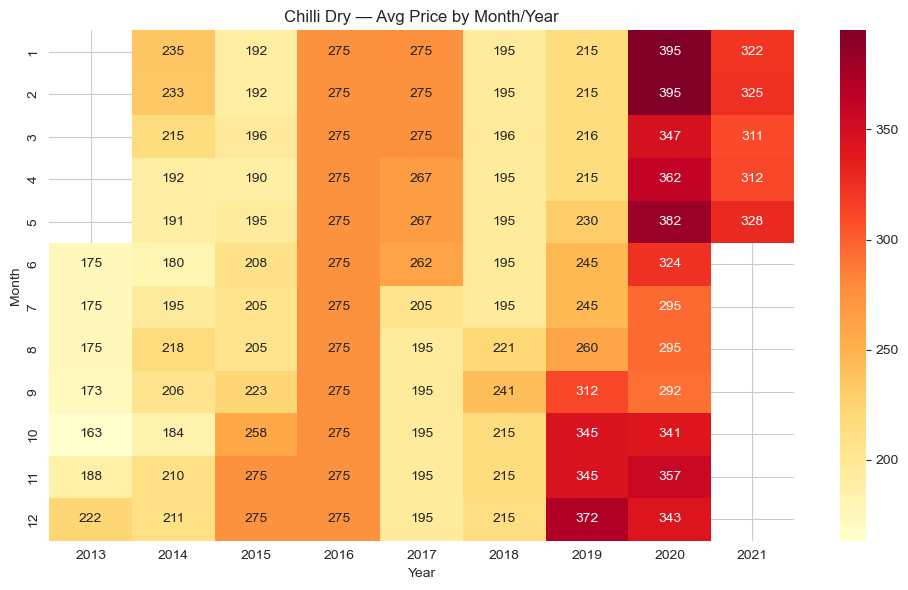

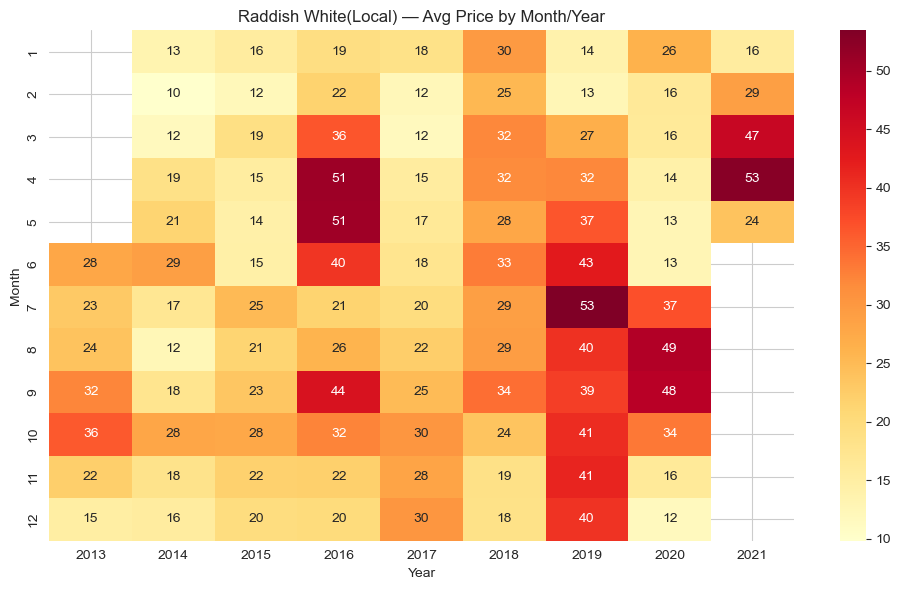

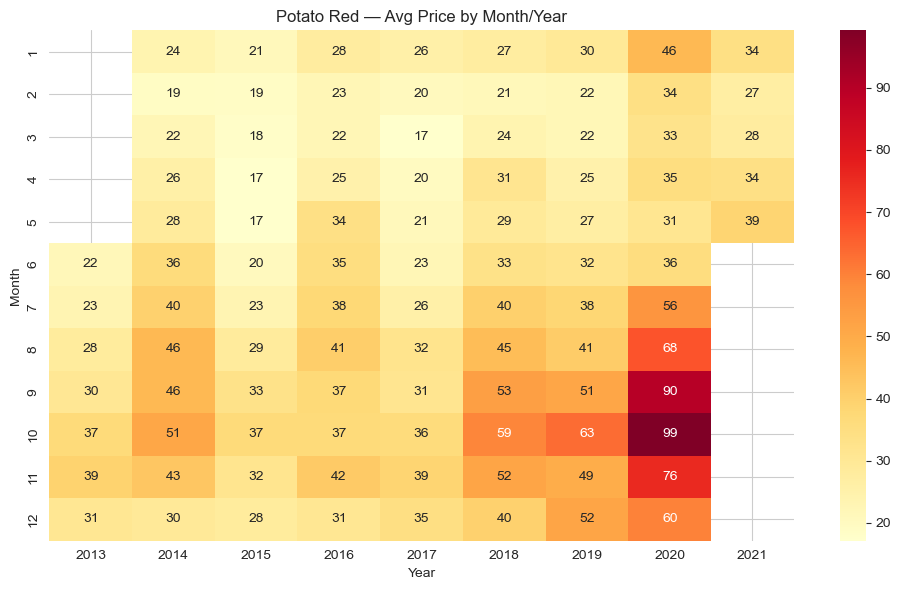

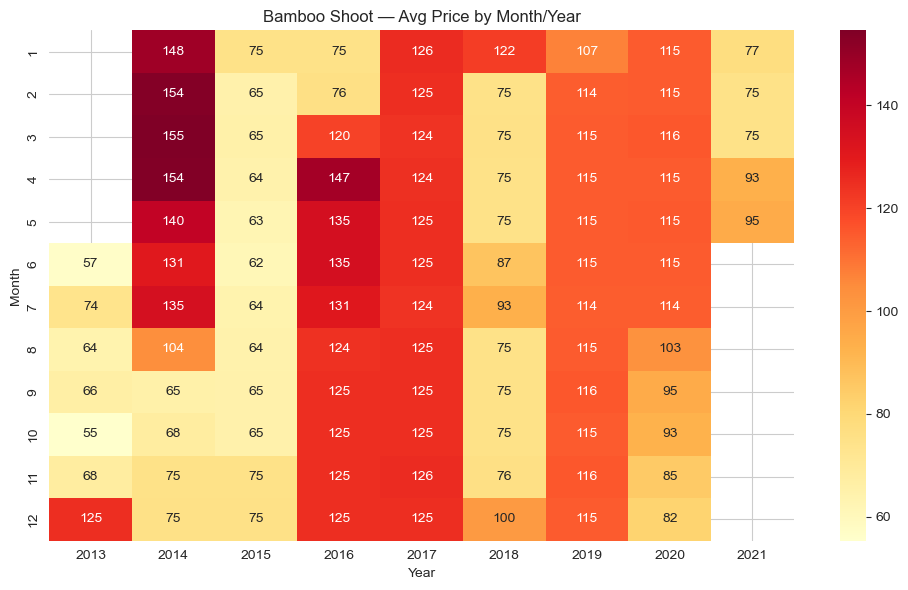

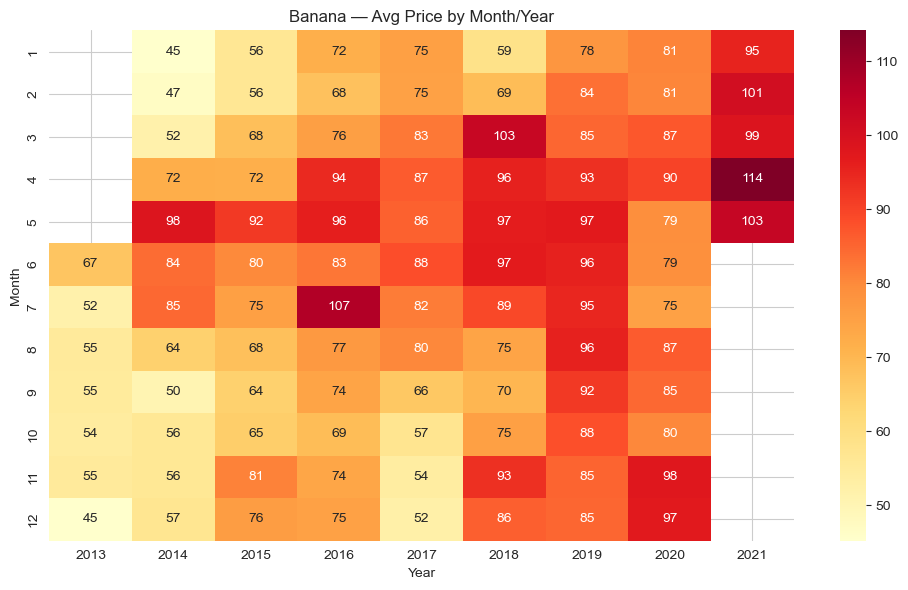

In [14]:
def yoy_heatmap(df, commodity):
    g = df[df[COMMODITY_COL] == commodity]
    pivot = g.pivot_table(index="Month", columns="Year", values="Average", aggfunc="mean")
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax)
    ax.set_title(f"{commodity} — Avg Price by Month/Year")
    plt.tight_layout()
    safe_name = commodity.replace("/", "_").replace(" ", "_")
    plt.savefig(f"{OUTPUT_DIR}/yoy_heatmap_{safe_name}.png", dpi=150)
    plt.show()

for c in top_commodities:
    yoy_heatmap(df, c)

## 7. Summary & Next Steps

Outputs saved to `./eda_outputs/`:
- `coverage_report.csv` — data completeness per commodity
- `volatility_ranking.csv` — CV and price-range volatility per commodity
- `seasonality_summary.csv` — seasonal strength, trend strength, peak month per commodity
- PNG plots for distributions, time series, STL decomposition, YoY heatmaps

**Next step:** use `volatility_ranking.csv` + `seasonality_summary.csv` as the feature set for the clustering step — grouping commodities by pricing *behavior* (volatility, seasonality strength, peak month) rather than raw price level.

In [15]:
print("\nData Types:")
print(df.dtypes)


Data Types:
Commodity                  object
Date               datetime64[ns]
Unit                       object
Minimum                   float64
Maximum                   float64
Average                   float64
Price_Range               float64
Price_Range_Pct           float64
Year                        int32
Month                       int32
Week                       UInt32
DayOfYear                   int32
dtype: object
